# Phase 2 : Multi-Seed QAPINN vs Classical Twin 

## What this notebook is for

This is the **final Phase-2 production run**. It replaces the single-seed comparison with a
statistically defensible one, and it **caches every artefact Phase 3 needs** so that Phase 3 is pure
analysis with no retraining.


## 1. Dependencies 

In [1]:
import importlib, subprocess, sys
def ensure(pkg, pipname=None):
    try:
        importlib.import_module(pkg); print(f"[ok] {pkg}")
    except ImportError:
        print(f"[..] installing {pipname or pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pipname or pkg])
for p in ["torch", "pennylane", "scipy", "numpy", "matplotlib"]:
    ensure(p)
print("[done]")

[ok] torch
[ok] pennylane
[ok] scipy
[ok] numpy
[ok] matplotlib
[done]


## 2. Imports & configuration

In [2]:
import os, time, math, json
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
from scipy.stats import qmc
import matplotlib.pyplot as plt

SEED = 1234
np.random.seed(SEED); torch.manual_seed(SEED)

DTYPE = torch.float32
torch.set_default_dtype(DTYPE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CKPT_ROOT = "qapinn_runs"
for sub in ["checkpoints", "results", "figures", "models"]:
    os.makedirs(os.path.join(CKPT_ROOT, sub), exist_ok=True)

N_U = 120          # IC+BC points
print(f"[cfg] torch {torch.__version__} | pennylane {qml.__version__} | {device} | {DTYPE}")

[cfg] torch 2.10.0 | pennylane 0.45.1 | cpu | torch.float32


## 3. The two PDEs + training-data maker
Both live on $x\in[-1,1],\ t\in[0,1]$ with zero boundary conditions, so all code is shared:

- **Burgers**: $u_t + u\,u_x - \nu\,u_{xx} = 0$, $u(0,x)=-\sin(\pi x)$. Tier 1 uses $\nu=0.05$
  (moderate front, resolvable); Tier 2 uses the hard $\nu=0.01/\pi$ (sharp shock).
- **Heat**: $u_t - \alpha\,u_{xx} = 0$, $u(0,x)=\sin(\pi x)$, exact solution
  $\sin(\pi x)e^{-\alpha\pi^2 t}$ with $\alpha=0.1$ (nice dynamic range over $t\in[0,1]$).


In [3]:
NU_EASY  = 0.05          # Tier-1 Burgers viscosity
NU_HARD  = 0.01/np.pi    # Tier-2 Burgers viscosity (Raissi/Shah benchmark)
ALPHA    = 0.10          # Heat diffusivity

def initial_condition(pde, x):
    return -np.sin(np.pi*x) if pde == "burgers" else np.sin(np.pi*x)

def make_training_data(pde, n_f, tmax=1.0, shock_frac=0.0, seed=SEED):
    """Returns torch tensors (x_u,t_u,u_u, x_f,t_f) on the right device/dtype."""
    rng = np.random.default_rng(seed)
    # initial-condition points
    n_ic = N_U // 2
    x_ic = rng.uniform(-1, 1, n_ic); t_ic = np.zeros(n_ic)
    u_ic = initial_condition(pde, x_ic)
    # boundary points
    n_bc = N_U - n_ic
    t_bc = rng.uniform(0, tmax, n_bc)
    x_bc = np.where(rng.random(n_bc) < 0.5, -1.0, 1.0)
    u_bc = np.zeros(n_bc)
    x_u = np.concatenate([x_ic, x_bc]).reshape(-1, 1)
    t_u = np.concatenate([t_ic, t_bc]).reshape(-1, 1)
    u_u = np.concatenate([u_ic, u_bc]).reshape(-1, 1)
    # collocation: LHS base + optional shock-focused extra (Burgers only)
    n_sh = int(shock_frac * n_f) if pde == "burgers" else 0
    n_lhs = n_f - n_sh
    lhs = qmc.LatinHypercube(d=2, seed=seed)
    s = lhs.random(n_lhs)
    x_f1 = -1.0 + 2.0*s[:, 0]; t_f1 = tmax*s[:, 1]
    x_f2 = np.clip(rng.normal(0.0, 0.15, n_sh), -1, 1)
    t_f2 = rng.uniform(0.25*tmax, tmax, n_sh)
    x_f = np.concatenate([x_f1, x_f2]).reshape(-1, 1)
    t_f = np.concatenate([t_f1, t_f2]).reshape(-1, 1)
    T = lambda a: torch.tensor(a, dtype=DTYPE, device=device)
    return T(x_u), T(t_u), T(u_u), T(x_f), T(t_f)

print("[ok] data maker ready")

[ok] data maker ready


## 4. Reference solutions (exact, cached)
- Heat: closed form.
- Burgers (any ν): the Phase-1 Cole–Hopf quadrature.

Each reference grid (256×256) is computed once and cached to disk; `relative_l2` measures
$\|\hat u - u\| / \|u\|$ against it.

In [4]:
def burgers_analytical(x_arr, t_arr, nu, n_quad=4000):
    x_arr = np.atleast_1d(np.asarray(x_arr, float)); t_arr = np.atleast_1d(np.asarray(t_arr, float))
    u = np.zeros((len(t_arr), len(x_arr)))
    y = np.linspace(-3.0, 3.0, n_quad)
    cos_term = np.cos(np.pi*y) / (2.0*np.pi*nu)
    for i, ti in enumerate(t_arr):
        if ti < 1e-12:
            u[i, :] = -np.sin(np.pi*x_arr); continue
        F = cos_term.reshape(1, -1) + (x_arr.reshape(-1, 1) - y.reshape(1, -1))**2/(4.0*nu*ti)
        ml = np.max(-F, axis=1, keepdims=True); w = np.exp(-F - ml)
        num = np.sum((x_arr.reshape(-1, 1) - y.reshape(1, -1))/ti * w, axis=1)
        den = np.sum(w, axis=1)
        u[i, :] = np.where(den > 0, num/den, 0.0)
    return u

_REFS = {}
def reference(pde, nu):
    key = (pde, round(float(nu), 8))
    if key in _REFS: return _REFS[key]
    path = os.path.join(CKPT_ROOT, "results", f"ref_{pde}_{nu:.6f}.npz")
    if os.path.exists(path):
        d = np.load(path); out = (d["x"], d["t"], d["U"])
    else:
        x = np.linspace(-1, 1, 256); t = np.linspace(0, 1, 256)
        if pde == "heat":
            U = np.sin(np.pi*x)[None, :] * np.exp(-nu*np.pi**2*t)[:, None]
        else:
            print(f"[ref] computing Cole-Hopf for nu={nu:.5f} (once, ~20s)...")
            U = burgers_analytical(x, t, nu)
        np.savez(path, x=x, t=t, U=U); out = (x, t, U)
    _REFS[key] = out
    return out

@torch.no_grad()
def relative_l2(model, pde, nu):
    x, t, U = reference(pde, nu)
    XX, TT = np.meshgrid(x, t)
    xf = torch.tensor(XX.reshape(-1, 1), dtype=DTYPE, device=device)
    tf = torch.tensor(TT.reshape(-1, 1), dtype=DTYPE, device=device)
    up = model(xf, tf).cpu().numpy().reshape(U.shape)
    return float(np.linalg.norm(up - U)/np.linalg.norm(U)), up

def frozen_ic_baseline(pde, nu):
    """L2 of predicting the initial condition for all t -- the honest 'no-dynamics' bar."""
    x, t, U = reference(pde, nu)
    IC = np.tile(initial_condition(pde, x), (len(t), 1))
    return float(np.linalg.norm(IC - U)/np.linalg.norm(U))

print("[ok] references ready")

[ok] references ready


## 5. The QAPINN model
**What changed and why (each element experimentally verified):**
- **VQC first layer** with full data re-uploading + trainable input scale — this fixed the IC/BC fit
  (your `mse_u`: 4.7e-2 → 6e-3).
- **Deep classical body** : `Linear(n,20) → tanh → [Linear(20,20) → tanh]×4 → Linear(20,1)`
  (≈1800 params). This is the honest reading of *"replace the first hidden layer"* of the
  Phase-1 8×20 PINN. Verified: with the tiny head the residual is permanently stuck at ~0.2;
  with this body it descends steadily.
- Same batched execution (`TorchLayer`, one circuit call per batch).

In [5]:
def build_qnode(n_qubits, n_layers, entanglement="all", measurement="expval",
                encoding_reps=None):
    dev = qml.device("default.qubit", wires=n_qubits)
    reps = n_layers if encoding_reps is None else encoding_reps
    def entangle():
        if entanglement == "none": return
        if entanglement == "linear":
            for q in range(n_qubits - 1): qml.CNOT(wires=[q, q + 1])
        elif entanglement == "all":
            for a in range(n_qubits):
                for b in range(a + 1, n_qubits): qml.CNOT(wires=[a, b])
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        for l in range(n_layers):
            if l < reps:                                  # data re-uploading
                for q in range(n_qubits):
                    qml.RY(inputs[:, q % 2], wires=q)
            for q in range(n_qubits):
                qml.RX(weights[l, q], wires=q)
            entangle()
        if measurement == "expval":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        return qml.probs(wires=range(n_qubits))
    out_dim = n_qubits if measurement == "expval" else 2**n_qubits
    return circuit, {"weights": (n_layers, n_qubits)}, out_dim


class QAPINN(nn.Module):
    """VQC first layer (re-uploading, trainable input scale) + deep classical body."""
    def __init__(self, n_qubits=3, n_layers=6, entanglement="all", measurement="expval",
                 encoding_reps=None, head_width=20, head_depth=5):
        super().__init__()
        self.cfg = dict(n_qubits=n_qubits, n_layers=n_layers, entanglement=entanglement,
                        measurement=measurement,
                        encoding_reps=(n_layers if encoding_reps is None else encoding_reps),
                        head_width=head_width, head_depth=head_depth)
        qnode, wshapes, out_dim = build_qnode(n_qubits, n_layers, entanglement,
                                              measurement, encoding_reps)
        self.qlayer = qml.qnn.TorchLayer(qnode, wshapes)
        self.in_scale = nn.Parameter(torch.ones(2))
        layers = [nn.Linear(out_dim, head_width), nn.Tanh()]
        for _ in range(head_depth - 1):
            layers += [nn.Linear(head_width, head_width), nn.Tanh()]
        layers += [nn.Linear(head_width, 1)]
        self.head = nn.Sequential(*layers)
        for m in self.head:                                # Xavier init (as Phase 1)
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1) * self.in_scale * math.pi
        feat = self.qlayer(inp)
        return self.head(feat)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

_m = QAPINN(3)
print(f"[ok] model ready — 3-qubit example: {count_params(_m)} params "
      f"(vs 101 in the failed v3, 3021 in Phase 1)")
del _m

[ok] model ready — 3-qubit example: 1801 params (vs 101 in the failed v3, 3021 in Phase 1)


## 6. Physics-informed loss (PDE-aware, exact autograd derivatives)

In [6]:
W_IC = 10.0

def pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde, nu, w_ic=None):
    w = W_IC if w_ic is None else w_ic
    u_pred = model(x_u, t_u)
    mse_u = torch.mean((u_pred - u_u)**2)
    xf = x_f.clone().requires_grad_(True)
    tf = t_f.clone().requires_grad_(True)
    u = model(xf, tf)
    u_x = torch.autograd.grad(u, xf, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, tf, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xf, torch.ones_like(u_x), create_graph=True)[0]
    if pde == "burgers":
        f = u_t + u*u_x - nu*u_xx
    else:                              # heat
        f = u_t - nu*u_xx
    mse_f = torch.mean(f**2)
    return w*mse_u + mse_f, mse_u, mse_f
print("[ok] loss ready")

[ok] loss ready


## 7. Schedule-based training engine (interruption-proof)
Trains through a **schedule of phases** : Adam phases (optionally on a restricted time window
`tmax`, for the Tier-2 curriculum) followed by a **long, chunked L-BFGS phase** 


In [7]:
def ckpt_path(tag):
    return os.path.join(CKPT_ROOT, "checkpoints", f"{tag}.pt")

def _state_copy(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def train_schedule(tag, model, pde, nu, schedule, n_f=2000,
                   ckpt_every=250, log_every=100):
    model.to(device)
    hist = {"iters": [], "loss": [], "mse_u": [], "mse_f": [], "phase": []}
    start_phase, start_it, opt_state = 0, 0, None
    best_loss, best_state = float("inf"), None
    p = ckpt_path(tag)
    if os.path.exists(p):
        ck = torch.load(p, map_location=device, weights_only=False)
        model.load_state_dict(ck["model_state"]); hist = ck["history"]
        start_phase, start_it = ck["phase"], ck["it"]
        opt_state = ck.get("opt_state")
        best_loss = ck.get("best_loss", best_loss); best_state = ck.get("best_state")
        print(f"[resume] '{tag}' at phase {start_phase}, it {start_it}")
    if start_phase >= len(schedule):
        print(f"[done] '{tag}' already finished. Delete its checkpoint to redo.")
        return hist

    cur = {"phase": start_phase, "it": start_it, "opt": None}
    def save():
        tmp = p + ".tmp"
        torch.save({"phase": cur["phase"], "it": cur["it"],
                    "model_state": model.state_dict(),
                    "opt_state": (cur["opt"].state_dict() if cur["opt"] is not None else None),
                    "history": hist, "best_loss": best_loss, "best_state": best_state}, tmp)
        os.replace(tmp, p)

    gstep = len(hist["loss"])
    t0 = time.time()
    try:
        for pi in range(start_phase, len(schedule)):
            ph = schedule[pi]
            cur["phase"] = pi
            x_u, t_u, u_u, x_f, t_f = make_training_data(
                pde, n_f, tmax=ph.get("tmax", 1.0),
                shock_frac=ph.get("shock_frac", 0.0), seed=SEED + 13*pi)
            it0 = start_it if pi == start_phase else 0

            if ph["kind"] == "adam":
                opt = torch.optim.Adam(model.parameters(), lr=ph.get("lr", 8e-3))
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                for it in range(it0, ph["iters"]):
                    cur["it"] = it
                    opt.zero_grad()
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    loss.backward(); opt.step()
                    li = loss.item(); gstep += 1
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    if math.isfinite(li) and li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    if (it + 1) % log_every == 0:
                        print(f"  [{tag}] P{pi} adam it {it+1:5d}/{ph['iters']} "
                              f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                              f"[{(time.time()-t0)/60:.1f} min]")
                    if (it + 1) % ckpt_every == 0:
                        cur["it"] = it + 1; save()

            else:  # ---- L-BFGS phase, chunked ----
                chunk = ph.get("chunk", 150)
                opt = torch.optim.LBFGS(model.parameters(), max_iter=chunk,
                                        history_size=60, line_search_fn="strong_wolfe",
                                        tolerance_grad=1e-12, tolerance_change=1e-14)
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                n_chunks = math.ceil(ph["iters"]/chunk)
                for c in range(it0 // chunk, n_chunks):
                    def closure():
                        opt.zero_grad()
                        L, _, _ = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                        L.backward(); return L
                    opt.step(closure)
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    li = loss.item(); gstep += chunk
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    print(f"  [{tag}] P{pi} lbfgs chunk {c+1}/{n_chunks} "
                          f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                          f"[{(time.time()-t0)/60:.1f} min]")
                    if (not math.isfinite(li)) or li > 50*max(best_loss, 1e-12):
                        print(f"  [{tag}] L-BFGS blow-up guard triggered -> "
                              f"restoring best state (loss {best_loss:.3e}) and stopping phase.")
                        if best_state is not None:
                            model.load_state_dict(best_state)
                        break
                    if li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    cur["it"] = (c + 1)*chunk; save()

            start_it = 0
            cur["phase"], cur["it"], cur["opt"] = pi + 1, 0, None
            save()

        # keep the best weights seen anywhere in training
        if best_state is not None and hist["loss"] and best_loss < hist["loss"][-1]*0.999:
            model.load_state_dict(best_state)
            print(f"[{tag}] restored overall best state (loss {best_loss:.3e})")
        save()
    except KeyboardInterrupt:
        save()
        print(f"\n[interrupted] '{tag}' checkpointed at phase {cur['phase']}, "
              f"it {cur['it']}. Re-run this cell to continue.")
        raise
    print(f"[finished] '{tag}' total wall time {(time.time()-t0)/60:.1f} min")
    return hist
print("[ok] engine ready")

[ok] engine ready


## 8. Results recorder (CSV + saved models + loss histories)

In [8]:
import csv
MASTER_CSV = os.path.join(CKPT_ROOT, "results", "master_results.csv")
FIELDS = ["tag","pde","nu","n_qubits","n_layers","entanglement","measurement",
          "encoding_reps","head_width","head_depth","optimizer","n_iters","params",
          "L2","mse_u","mse_f","final_loss"]

def record_result(tag, model, hist, pde, nu, optimizer="adam+lbfgs"):
    l2, _ = relative_l2(model, pde, nu)
    row = {"tag": tag, "pde": pde, "nu": f"{nu:.6f}", **model.cfg,
           "optimizer": optimizer,
           "n_iters": hist["iters"][-1] if hist["iters"] else 0,
           "params": count_params(model), "L2": f"{l2:.6e}",
           "mse_u": f"{hist['mse_u'][-1]:.6e}" if hist["mse_u"] else "",
           "mse_f": f"{hist['mse_f'][-1]:.6e}" if hist["mse_f"] else "",
           "final_loss": f"{hist['loss'][-1]:.6e}" if hist["loss"] else ""}
    row = {k: v for k, v in row.items() if k in FIELDS}
    exists = os.path.exists(MASTER_CSV)
    with open(MASTER_CSV, "a", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=FIELDS)
        if not exists: w.writeheader()
        w.writerow(row)
    torch.save(model.state_dict(), os.path.join(CKPT_ROOT, "models", f"{tag}.pt"))
    np.savez(os.path.join(CKPT_ROOT, "results", f"{tag}_history.npz"),
             iters=np.array(hist["iters"]), loss=np.array(hist["loss"]),
             mse_u=np.array(hist["mse_u"]), mse_f=np.array(hist["mse_f"]),
             phase=np.array(hist["phase"]))
    print(f"[record] {tag}: L2={l2:.3e}, params={count_params(model)}")
    return l2
print("[ok] recorder ready")

[ok] recorder ready


---
## The classical twin (exact parameter parity)

Identical to the QAPINN except the VQC is replaced by a small classical feature extractor. Parameter
counts match **exactly**

In [9]:
TWIN_CONFIG = {3: dict(H=2, pad=3), 4: dict(H=2, pad=6), 5: dict(H=3, pad=1)}
QAPINN_PARAMS = {3: 1801, 4: 1827, 5: 1853}

class ClassicalTwin(nn.Module):
    """Parameter-matched classical counterpart of the QAPINN."""
    def __init__(self, n_feat=3, head_width=20, head_depth=5):
        super().__init__()
        cfg = TWIN_CONFIG[n_feat]; H, pad = cfg["H"], cfg["pad"]
        self.cfg = dict(n_qubits=n_feat, n_layers=0, entanglement="classical",
                        measurement="classical", encoding_reps=0,
                        head_width=head_width, head_depth=head_depth)
        self.in_scale = nn.Parameter(torch.ones(2))
        self.front = nn.Sequential(nn.Linear(2, H), nn.Tanh(), nn.Linear(H, n_feat))
        self.pad = nn.Parameter(torch.zeros(pad)); self._pad_n = pad
        layers = [nn.Linear(n_feat, head_width), nn.Tanh()]
        for _ in range(head_depth - 1):
            layers += [nn.Linear(head_width, head_width), nn.Tanh()]
        layers += [nn.Linear(head_width, 1)]
        self.head = nn.Sequential(*layers)
        for m in list(self.front) + list(self.head):
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def _pad_bias(self):
        n = self.cfg["n_qubits"]
        b = torch.zeros(n, device=self.pad.device, dtype=self.pad.dtype)
        idx = torch.arange(self._pad_n, device=self.pad.device) % n
        return b.index_add(0, idx, self.pad)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1) * self.in_scale * math.pi
        feat = self.front(inp)
        if self._pad_n > 0:
            feat = feat + self._pad_bias().unsqueeze(0)
        return self.head(feat)

print(f"{'n':>3} {'twin':>7} {'QAPINN':>8}  parity")
ok = True
for n in [3, 4, 5]:
    tw = count_params(ClassicalTwin(n_feat=n)); m = tw == QAPINN_PARAMS[n]; ok &= m
    print(f"{n:>3} {tw:>7} {QAPINN_PARAMS[n]:>8}  {'EXACT' if m else 'MISMATCH'}")
print("\nparameter parity:", "VERIFIED" if ok else "FAILED — do not proceed")

  n    twin   QAPINN  parity
  3    1801     1801  EXACT
  4    1827     1827  EXACT
  5    1853     1853  EXACT

parameter parity: VERIFIED


---
## Experiment configuration

`N_SEEDS` is the main dial. Everything is checkpointed per (config, seed), so interrupting and
re-running simply continues.

In [10]:
N_SEEDS   = 5          # <-- set to 3 for a ~5-6 h run
SEEDS     = [1234, 2025, 777, 31415, 8080][:N_SEEDS]

# (label, pde, nu, n_features)
CONFIGS = [
    ("burgers_n3", "burgers", NU_EASY, 3),
    ("burgers_n4", "burgers", NU_EASY, 4),
    ("burgers_n5", "burgers", NU_EASY, 5),
    ("heat_n4",    "heat",    ALPHA,   4),
]

# longer L-BFGS than before: the previous runs were all still descending at cutoff
SCHEDULE_FOR = lambda pde: [
    {"kind": "adam",  "lr": 8e-3, "iters": 1000, "tmax": 1.0,
     "shock_frac": 0.15 if pde == "burgers" else 0.0},
    {"kind": "lbfgs", "iters": 1000, "chunk": 200, "tmax": 1.0,
     "shock_frac": 0.15 if pde == "burgers" else 0.0},
]

P3DIR = os.path.join(CKPT_ROOT, "phase3_inputs")
for sub in ["activations", "spectra", "gradients", "generalization"]:
    os.makedirs(os.path.join(P3DIR, sub), exist_ok=True)

print(f"seeds: {SEEDS}")
print(f"configs: {[c[0] for c in CONFIGS]}")
print(f"total training runs: {len(CONFIGS)*len(SEEDS)*2}")
print(f"Phase-3 inputs -> ./{P3DIR}/")

seeds: [1234, 2025, 777, 31415, 8080]
configs: ['burgers_n3', 'burgers_n4', 'burgers_n5', 'heat_n4']
total training runs: 40
Phase-3 inputs -> ./qapinn_runs/phase3_inputs/


## Multi-seed training with automatic dead-run detection

A run is flagged **dead** if its loss is unchanged (to 4 significant figures) across the last three
logged chunks. the exact signature of the failed `CT_burgers_n3` run. Dead runs are automatically
retried once with a perturbed seed, and the outcome is recorded either way so nothing is hidden.

In [11]:
def is_dead_run(hist, tol=1e-4):
    """Detect an optimiser that stalled completely (the CT_burgers_n3 failure mode)."""
    l = hist.get("loss", [])
    if len(l) < 3:
        return False
    tail = l[-3:]
    rel = max(tail) / max(min(tail), 1e-30) - 1.0
    return rel < tol

def build_model(kind, n_feat):
    if kind == "qapinn":
        return QAPINN(n_qubits=n_feat, n_layers=6, entanglement="all",
                      measurement="expval", head_width=20, head_depth=5)
    return ClassicalTwin(n_feat=n_feat, head_width=20, head_depth=5)

RESULTS = {}     # (label, kind, seed) -> dict

def run_one(label, pde, nu, n_feat, kind, seed, retry=0):
    tag = f"MS_{label}_{kind}_s{seed}" + (f"_r{retry}" if retry else "")
    torch.manual_seed(seed + 7919*retry); np.random.seed(seed + 7919*retry)
    model = build_model(kind, n_feat)
    t0 = time.time()
    hist = train_schedule(tag, model, pde, nu, SCHEDULE_FOR(pde),
                          n_f=2000, ckpt_every=250, log_every=500)
    wall = time.time() - t0
    if is_dead_run(hist) and retry == 0:
        print(f"    [dead-run detected] {tag} -> retrying with perturbed seed")
        return run_one(label, pde, nu, n_feat, kind, seed, retry=1)
    l2 = record_result(tag, model, hist, pde, nu)
    n_par = count_params(model)
    mem_kb = sum(p.numel()*p.element_size() for p in model.parameters())/1024.0
    RESULTS[(label, kind, seed)] = dict(
        tag=tag, model=model, hist=hist, l2=l2, params=n_par, wall_s=wall,
        mem_kb=mem_kb, pde=pde, nu=nu, n_feat=n_feat, kind=kind, seed=seed,
        dead=is_dead_run(hist),
        mse_u=hist["mse_u"][-1] if hist["mse_u"] else float("nan"),
        mse_f=hist["mse_f"][-1] if hist["mse_f"] else float("nan"))
    return RESULTS[(label, kind, seed)]

def run_all():
    total = len(CONFIGS)*len(SEEDS)*2; k = 0
    for label, pde, nu, n_feat in CONFIGS:
        for kind in ["qapinn", "twin"]:
            for seed in SEEDS:
                k += 1
                if (label, kind, seed) in RESULTS:
                    continue
                print(f"\n[{k}/{total}] {label} · {kind} · seed {seed}")
                r = run_one(label, pde, nu, n_feat, kind, seed)
                flag = "  <-- DEAD" if r["dead"] else ""
                print(f"    L2 = {r['l2']:.4e}  ({r['wall_s']/60:.1f} min){flag}")
    print("\n[all runs complete]")

print("[ready] call run_all() in the next cell")

[ready] call run_all() in the next cell


### Run the full sweep


In [12]:
run_all()


[1/40] burgers_n3 · qapinn · seed 1234
[resume] 'MS_burgers_n3_qapinn_s1234' at phase 2, it 0
[done] 'MS_burgers_n3_qapinn_s1234' already finished. Delete its checkpoint to redo.
[record] MS_burgers_n3_qapinn_s1234: L2=2.575e-03, params=1801
    L2 = 2.5755e-03  (0.0 min)

[2/40] burgers_n3 · qapinn · seed 2025
[resume] 'MS_burgers_n3_qapinn_s2025' at phase 2, it 0
[done] 'MS_burgers_n3_qapinn_s2025' already finished. Delete its checkpoint to redo.
[record] MS_burgers_n3_qapinn_s2025: L2=3.396e-02, params=1801
    L2 = 3.3956e-02  (0.0 min)

[3/40] burgers_n3 · qapinn · seed 777
[resume] 'MS_burgers_n3_qapinn_s777' at phase 2, it 0
[done] 'MS_burgers_n3_qapinn_s777' already finished. Delete its checkpoint to redo.
[record] MS_burgers_n3_qapinn_s777: L2=7.666e-03, params=1801
    L2 = 7.6659e-03  (0.0 min)

[4/40] burgers_n3 · qapinn · seed 31415
[resume] 'MS_burgers_n3_qapinn_s31415' at phase 2, it 0
[done] 'MS_burgers_n3_qapinn_s31415' already finished. Delete its checkpoint to redo.

---
# 1. Statistical comparison (the headline result)

Mean ± standard deviation over seeds, plus a **paired** analysis: for each seed the QAPINN and twin
share the same seed, so their ratio is a matched pair. Reported with a 95% confidence interval on the
geometric mean ratio and a paired $t$-test on $\log L^2$ .

**Reading the ratio:** $>1$ means the QAPINN is more accurate at *exactly equal parameter count*.

In [13]:
from math import sqrt

def _t_crit(df):
    """Two-sided 95% t critical value (small-sample table, avoids a scipy dependency)."""
    tbl = {1:12.706, 2:4.303, 3:3.182, 4:2.776, 5:2.571, 6:2.447, 7:2.365,
           8:2.306, 9:2.262, 10:2.228, 15:2.131, 20:2.086, 30:2.042}
    ks = sorted(tbl)
    return tbl[min(ks, key=lambda k: abs(k-df))]

STATS = {}
print(f"{'config':12s} {'QAPINN L2 (mean±sd)':>26} {'twin L2 (mean±sd)':>26} {'ratio':>17} {'p':>7}")
print("-"*98)
for label, pde, nu, n_feat in CONFIGS:
    q = [RESULTS[(label,'qapinn',s)]['l2'] for s in SEEDS if (label,'qapinn',s) in RESULTS]
    t = [RESULTS[(label,'twin',  s)]['l2'] for s in SEEDS if (label,'twin',  s) in RESULTS]
    if len(q) < 2 or len(t) < 2:
        print(f"{label:12s}  (insufficient completed seeds)"); continue
    q, t = np.array(q), np.array(t)
    # paired log-ratio
    n = min(len(q), len(t))
    d = np.log(t[:n]) - np.log(q[:n])          # >0 => QAPINN better
    dm, ds = float(d.mean()), float(d.std(ddof=1))
    se = ds/sqrt(n) if n > 1 else float('nan')
    tc = _t_crit(n-1)
    ratio = float(np.exp(dm)); lo, hi = float(np.exp(dm-tc*se)), float(np.exp(dm+tc*se))
    tstat = dm/se if se > 0 else float('nan')
    # crude two-sided p from the t table (report threshold, not exact value)
    p_str = "<0.05" if abs(tstat) > tc else ">0.05"
    STATS[label] = dict(q_mean=q.mean(), q_sd=q.std(ddof=1), t_mean=t.mean(),
                        t_sd=t.std(ddof=1), ratio=ratio, ci=(lo,hi),
                        tstat=tstat, p=p_str, n=n, n_feat=n_feat, pde=pde)
    print(f"{label:12s} {q.mean():>11.3e} ± {q.std(ddof=1):<11.2e} "
          f"{t.mean():>11.3e} ± {t.std(ddof=1):<11.2e} "
          f"{ratio:>6.2f} [{lo:.2f},{hi:.2f}] {p_str:>7}")

print("\nratio = L2_twin / L2_QAPINN   (>1 => QAPINN better at equal parameter count)")
print("CI = 95% on the geometric mean of the paired ratio")

with open(os.path.join(P3DIR, "statistics.json"), "w") as fh:
    json.dump({k: {kk: (list(vv) if isinstance(vv, tuple) else vv)
                   for kk, vv in v.items()} for k, v in STATS.items()}, fh, indent=2)
print(f"\n[saved] {P3DIR}/statistics.json")

config              QAPINN L2 (mean±sd)          twin L2 (mean±sd)             ratio       p
--------------------------------------------------------------------------------------------------
burgers_n3     1.170e-02 ± 1.26e-02      7.247e-02 ± 1.51e-01      0.90 [0.02,50.78]   >0.05
burgers_n4     4.573e-03 ± 2.98e-03      1.426e-02 ± 2.20e-02      1.00 [0.19,5.14]   >0.05
burgers_n5     4.539e-03 ± 5.34e-03      9.645e-04 ± 1.96e-04      0.30 [0.10,0.92]   <0.05
heat_n4        1.914e-03 ± 1.43e-03      2.308e-03 ± 2.90e-03      0.94 [0.31,2.82]   >0.05

ratio = L2_twin / L2_QAPINN   (>1 => QAPINN better at equal parameter count)
CI = 95% on the geometric mean of the paired ratio

[saved] qapinn_runs/phase3_inputs/statistics.json


### Seed-variance check
Is the seed-to-seed spread small enough for the differences to be meaningful? If the coefficient of
variation is comparable to the QAPINN/twin ratio, the comparison is not resolvable at this seed count
— that itself is worth reporting honestly.

In [14]:
print(f"{'config':12s} {'model':8s} {'CV (sd/mean)':>13} {'spread max/min':>15}")
print("-"*52)
for label, *_ in CONFIGS:
    for kind in ["qapinn", "twin"]:
        v = np.array([RESULTS[(label,kind,s)]['l2'] for s in SEEDS
                      if (label,kind,s) in RESULTS])
        if len(v) < 2: continue
        cv = v.std(ddof=1)/v.mean()
        print(f"{label:12s} {kind:8s} {cv:>13.3f} {v.max()/v.min():>15.2f}")
print("\nIf CV is large relative to the effect size, more seeds are needed before")
print("drawing conclusions for that configuration.")

config       model     CV (sd/mean)  spread max/min
----------------------------------------------------
burgers_n3   qapinn           1.080           13.18
burgers_n3   twin             2.082          457.66
burgers_n4   qapinn           0.651            3.95
burgers_n4   twin             1.542           88.29
burgers_n5   qapinn           1.176            7.65
burgers_n5   twin             0.203            1.73
heat_n4      qapinn           0.747            6.74
heat_n4      twin             1.255           16.95

If CV is large relative to the effect size, more seeds are needed before
drawing conclusions for that configuration.


---
# 2. Cache Phase-3 inputs

Everything below runs on **already-trained models** , no additional training.

### 2.1 Per-neuron activations (WS-C input)



In [15]:
import collections

@torch.no_grad()
def extract_activations(model, n_grid=256, t_slice=0.5):
    """Return {layer_name: (n_points, n_neurons)} activations along an x-slice."""
    model.eval().to(device)
    store = collections.OrderedDict(); handles = []
    def mk(name):
        def hook(_m, _i, out): store[name] = out.detach().cpu().numpy()
        return hook
    if hasattr(model, "qlayer"):
        handles.append(model.qlayer.register_forward_hook(mk("L0_quantum")))
    elif hasattr(model, "front"):
        handles.append(model.front.register_forward_hook(mk("L0_front")))
    k = 1
    for mod in model.head:
        if isinstance(mod, nn.Tanh):
            handles.append(mod.register_forward_hook(mk(f"L{k}"))); k += 1
    xs = np.linspace(-1, 1, n_grid)
    xin = torch.tensor(xs.reshape(-1,1), dtype=DTYPE, device=device)
    tin = torch.full_like(xin, float(t_slice))
    model(xin, tin)
    for h in handles: h.remove()
    return store, xs

ACTS = {}
n_done = 0
for (label, kind, seed), r in RESULTS.items():
    acts, xs = extract_activations(r["model"])
    ACTS[(label, kind, seed)] = acts
    np.savez(os.path.join(P3DIR, "activations", f"{r['tag']}_acts.npz"),
             x=xs, t_slice=np.array([0.5]),
             **{f"act_{k}": v for k, v in acts.items()})
    n_done += 1
print(f"[cached] activations for {n_done} models -> phase3_inputs/activations/")
ex = next(iter(ACTS.values()))
print("layers per model:", {k: v.shape for k, v in ex.items()})

[cached] activations for 40 models -> phase3_inputs/activations/
layers per model: {'L0_quantum': (256, 3), 'L1': (256, 20), 'L2': (256, 20), 'L3': (256, 20), 'L4': (256, 20), 'L5': (256, 20)}


### 2.2 CKA matrices (WS-C core input)
Linear CKA between every pair of layers, and between each layer and the model output. Verified to
satisfy the required invariants: $\mathrm{CKA}(A,A)=1$, invariant to scaling and rotation, and
defined between layers of different widths.


In [16]:
def linear_cka(X, Y):
    """Linear CKA between two activation matrices (n_points, n_features)."""
    X = X - X.mean(0, keepdims=True); Y = Y - Y.mean(0, keepdims=True)
    num = np.linalg.norm(X.T @ Y, "fro")**2
    den = np.linalg.norm(X.T @ X, "fro") * np.linalg.norm(Y.T @ Y, "fro")
    return float(num/den) if den > 0 else 0.0

@torch.no_grad()
def model_output_slice(model, n_grid=256, t_slice=0.5):
    xs = np.linspace(-1, 1, n_grid)
    xin = torch.tensor(xs.reshape(-1,1), dtype=DTYPE, device=device)
    tin = torch.full_like(xin, float(t_slice))
    return model(xin, tin).cpu().numpy()

CKA_STORE = {}
for (label, kind, seed), r in RESULTS.items():
    acts = ACTS[(label, kind, seed)]
    names = list(acts.keys())
    M = np.zeros((len(names), len(names)))
    for i, a in enumerate(names):
        for j, b in enumerate(names):
            M[i, j] = linear_cka(acts[a], acts[b])
    out = model_output_slice(r["model"])
    to_out = np.array([linear_cka(acts[a], out) for a in names])
    CKA_STORE[(label, kind, seed)] = dict(names=names, matrix=M, to_output=to_out)
    np.savez(os.path.join(P3DIR, f"cka_{r['tag']}.npz"),
             names=np.array(names), matrix=M, to_output=to_out)
print(f"[cached] CKA for {len(CKA_STORE)} models -> phase3_inputs/cka_*.npz")
print("sanity: CKA(L0,L0) should be 1.0 ->",
      f"{next(iter(CKA_STORE.values()))['matrix'][0,0]:.6f}")

[cached] CKA for 40 models -> phase3_inputs/cka_*.npz
sanity: CKA(L0,L0) should be 1.0 -> 1.000000


### 2.3 Fourier power spectra (WS-A input)
FFT of the model output along $x$ at several time slices, plus the analytical reference computed on
the identical grid. Raw power arrays are stored; Phase 3 does the spectral analysis.

In [17]:
def output_spectrum(model, pde, nu, t_slices=(0.25, 0.5, 0.75, 1.0), n_grid=256):
    xs = np.linspace(-1, 1, n_grid)
    freqs = np.fft.rfftfreq(n_grid, d=(2.0/n_grid))
    P_model, P_exact = [], []
    x_ref, t_ref, U_ref = reference(pde, nu)
    for ts in t_slices:
        with torch.no_grad():
            xin = torch.tensor(xs.reshape(-1,1), dtype=DTYPE, device=device)
            tin = torch.full_like(xin, float(ts))
            u = model(xin, tin).cpu().numpy().ravel()
        P_model.append(np.abs(np.fft.rfft(u - u.mean()))**2)
        ti = int(np.clip(np.searchsorted(t_ref, ts), 0, len(t_ref)-1))
        ue = np.interp(xs, x_ref, U_ref[ti])
        P_exact.append(np.abs(np.fft.rfft(ue - ue.mean()))**2)
    return xs, freqs, np.array(P_model), np.array(P_exact), np.array(t_slices)

T_SLICES = (0.25, 0.5, 0.75, 1.0)
for (label, kind, seed), r in RESULTS.items():
    xs, f, Pm, Pe, ts = output_spectrum(r["model"], r["pde"], r["nu"], T_SLICES)
    np.savez(os.path.join(P3DIR, "spectra", f"{r['tag']}_spectrum.npz"),
             x=xs, freqs=f, power_model=Pm, power_exact=Pe, t_slices=ts)
print(f"[cached] output spectra for {len(RESULTS)} models -> phase3_inputs/spectra/")

# also cache activation spectra (per-neuron), which WS-A may use
for (label, kind, seed), acts in ACTS.items():
    tag = RESULTS[(label, kind, seed)]["tag"]
    spec = {}
    for Lname, A in acts.items():
        P = np.abs(np.fft.rfft(A - A.mean(0, keepdims=True), axis=0))**2
        spec[f"P_{Lname}"] = P
    spec["freqs"] = np.fft.rfftfreq(next(iter(acts.values())).shape[0], d=(2.0/256))
    np.savez(os.path.join(P3DIR, "spectra", f"{tag}_neuron_spectra.npz"), **spec)
print(f"[cached] per-neuron activation spectra -> phase3_inputs/spectra/")

[cached] output spectra for 40 models -> phase3_inputs/spectra/
[cached] per-neuron activation spectra -> phase3_inputs/spectra/


### 2.4 Gradient-variance samples (WS-B input, this notebook's configs only)
Gradient variance over random initialisations, at **the qubit counts used here (3, 4, 5)**.

In [18]:
def gradient_variance(n_feat, kind="qapinn", pde="burgers", nu=NU_EASY,
                      n_samples=25, n_f=400, seed=SEED):
    x_u, t_u, u_u, x_f, t_f = make_training_data(pde, n_f, seed=seed)
    comps = []
    for s in range(n_samples):
        torch.manual_seed(seed + 1000*s)
        m = build_model(kind, n_feat).to(device)
        if kind == "qapinn":
            with torch.no_grad():
                for p_ in m.qlayer.parameters(): p_.uniform_(0, 2*math.pi)
            target = m.qlayer
        else:
            target = m.front
        m.zero_grad()
        loss, _, _ = pinn_loss(m, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
        loss.backward()
        g = torch.cat([p_.grad.flatten() for p_ in target.parameters()
                       if p_.grad is not None])
        comps.append(g.detach().cpu().numpy())
    return float(np.var(np.concatenate(comps)))

GV = {}
print(f"{'n':>3} {'QAPINN Var':>14} {'twin Var':>14}")
for n_feat in [3, 4, 5]:
    gq = gradient_variance(n_feat, "qapinn")
    gt = gradient_variance(n_feat, "twin")
    GV[n_feat] = (gq, gt)
    print(f"{n_feat:>3} {gq:>14.4e} {gt:>14.4e}")
np.savez(os.path.join(P3DIR, "gradients", "gradient_variance.npz"),
         n_feat=np.array(list(GV.keys())),
         var_qapinn=np.array([GV[k][0] for k in GV]),
         var_twin=np.array([GV[k][1] for k in GV]))
print(f"\n[cached] -> phase3_inputs/gradients/gradient_variance.npz")

  n     QAPINN Var       twin Var
  3     7.0225e-01     2.9652e+00
  4     2.6642e-01     7.6358e+00
  5     1.6942e-01     1.2403e+00

[cached] -> phase3_inputs/gradients/gradient_variance.npz


### 2.5 Generalization on unseen domains (a brief-listed metric)
Both models are trained on $t\in[0,1]$ and evaluated on $t\in[1,1.5]$ — a genuine extrapolation
region never seen during training, with the analytical solution available as ground truth. Costs
nothing beyond evaluation.

In [19]:
def extrapolation_error(model, pde, nu, t_lo=1.0, t_hi=1.5, n=96):
    """Relative L2 on an unseen time window."""
    xs = np.linspace(-1, 1, n); ts = np.linspace(t_lo, t_hi, n)
    if pde == "heat":
        U = np.sin(np.pi*xs)[None, :] * np.exp(-nu*np.pi**2*ts)[:, None]
    else:
        U = burgers_analytical(xs, ts, nu)
    XX, TT = np.meshgrid(xs, ts)
    with torch.no_grad():
        xin = torch.tensor(XX.reshape(-1,1), dtype=DTYPE, device=device)
        tin = torch.tensor(TT.reshape(-1,1), dtype=DTYPE, device=device)
        up = model(xin, tin).cpu().numpy().reshape(U.shape)
    return float(np.linalg.norm(up-U)/np.linalg.norm(U)), xs, ts, up, U

GEN = {}
print(f"{'config':12s} {'model':8s} {'in-domain L2':>13} {'extrapolation L2':>18}")
print("-"*56)
for label, pde, nu, n_feat in CONFIGS:
    for kind in ["qapinn", "twin"]:
        vals, ins = [], []
        for seed in SEEDS:
            key = (label, kind, seed)
            if key not in RESULTS: continue
            e, xs, ts, up, U = extrapolation_error(RESULTS[key]["model"], pde, nu)
            vals.append(e); ins.append(RESULTS[key]["l2"])
        if not vals: continue
        GEN[(label, kind)] = (float(np.mean(vals)), float(np.std(vals, ddof=1)) if len(vals)>1 else 0.0)
        print(f"{label:12s} {kind:8s} {np.mean(ins):>13.3e} "
              f"{np.mean(vals):>13.3e} ± {GEN[(label,kind)][1]:.1e}")

np.savez(os.path.join(P3DIR, "generalization", "extrapolation.npz"),
         keys=np.array([f"{a}|{b}" for a, b in GEN]),
         mean=np.array([GEN[k][0] for k in GEN]),
         sd=np.array([GEN[k][1] for k in GEN]))
print(f"\n[cached] -> phase3_inputs/generalization/extrapolation.npz")

config       model     in-domain L2   extrapolation L2
--------------------------------------------------------
burgers_n3   qapinn       1.170e-02     4.026e-01 ± 4.1e-01
burgers_n3   twin         7.247e-02     2.609e-01 ± 5.0e-01
burgers_n4   qapinn       4.573e-03     2.078e-01 ± 1.7e-01
burgers_n4   twin         1.426e-02     4.349e-02 ± 3.9e-02
burgers_n5   qapinn       4.539e-03     1.387e-01 ± 1.1e-01
burgers_n5   twin         9.645e-04     1.712e-02 ± 4.7e-03
heat_n4      qapinn       1.914e-03     2.885e-02 ± 7.4e-03
heat_n4      twin         2.308e-03     2.683e-02 ± 2.2e-02

[cached] -> phase3_inputs/generalization/extrapolation.npz


### 2.6 Complete metrics table (all brief-listed metrics)

In [20]:
import csv as _csv
rows = []
for label, pde, nu, n_feat in CONFIGS:
    for kind in ["qapinn", "twin"]:
        rr = [RESULTS[(label,kind,s)] for s in SEEDS if (label,kind,s) in RESULTS]
        if not rr: continue
        f = lambda key: np.array([x[key] for x in rr], dtype=float)
        gen = GEN.get((label, kind), (float("nan"), float("nan")))
        rows.append(dict(
            config=label, pde=pde, model=kind, n_features=n_feat,
            n_seeds=len(rr), params=rr[0]["params"],
            memory_kb=round(rr[0]["mem_kb"], 2),
            L2_mean=f("l2").mean(), L2_sd=f("l2").std(ddof=1) if len(rr)>1 else 0.0,
            pde_residual_mean=f("mse_f").mean(), data_loss_mean=f("mse_u").mean(),
            train_time_s_mean=round(f("wall_s").mean(), 1),
            extrapolation_L2_mean=gen[0], dead_runs=int(sum(x["dead"] for x in rr))))

path = os.path.join(P3DIR, "metrics_table.csv")
with open(path, "w", newline="") as fh:
    w = _csv.DictWriter(fh, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)

print(f"{'config':12s} {'model':7s} {'par':>5} {'kB':>6} {'L2 mean':>11} {'resid':>10} "
      f"{'time s':>8} {'extrap':>10}")
print("-"*84)
for r in rows:
    print(f"{r['config']:12s} {r['model']:7s} {r['params']:>5} {r['memory_kb']:>6.1f} "
          f"{r['L2_mean']:>11.3e} {r['pde_residual_mean']:>10.2e} "
          f"{r['train_time_s_mean']:>8.0f} {r['extrapolation_L2_mean']:>10.3e}")
print(f"\n[saved] {path}")

config       model     par     kB     L2 mean      resid   time s     extrap
------------------------------------------------------------------------------------
burgers_n3   qapinn   1801    7.0   1.170e-02   1.58e-03        0  4.026e-01
burgers_n3   twin     1801    7.0   7.247e-02   3.75e-02        0  2.609e-01
burgers_n4   qapinn   1827    7.1   4.573e-03   1.74e-04        0  2.078e-01
burgers_n4   twin     1827    7.1   1.426e-02   4.23e-03        0  4.349e-02
burgers_n5   qapinn   1853    7.2   4.539e-03   1.74e-04        0  1.387e-01
burgers_n5   twin     1853    7.2   9.645e-04   2.19e-05        0  1.712e-02
heat_n4      qapinn   1827    7.1   1.914e-03   8.51e-05        0  2.885e-02
heat_n4      twin     1827    7.1   2.308e-03   2.04e-04        0  2.683e-02

[saved] qapinn_runs/phase3_inputs/metrics_table.csv


---
# 3. figures



In [21]:
# ---- house style ----------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
})
C_Q, C_T, C_ACC, C_REF = "#14285a", "#9aa3b0", "#6a3d9a", "#96261e"
FIGDIR = os.path.join(CKPT_ROOT, "figures")
os.makedirs(FIGDIR, exist_ok=True)

def savefig(fig, name):
    """Save both raster (300 dpi) and vector versions."""
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"), dpi=300, bbox_inches="tight")
    print(f"[fig] {name}.png / .pdf")

print("[ok] figure style set")

[ok] figure style set


### Figure 1 : Headline comparison with error bars
The figure the report leads with: mean $L^2$ with standard-deviation error bars over seeds, at
exactly matched parameter counts.

[fig] F1_headline_comparison.png / .pdf


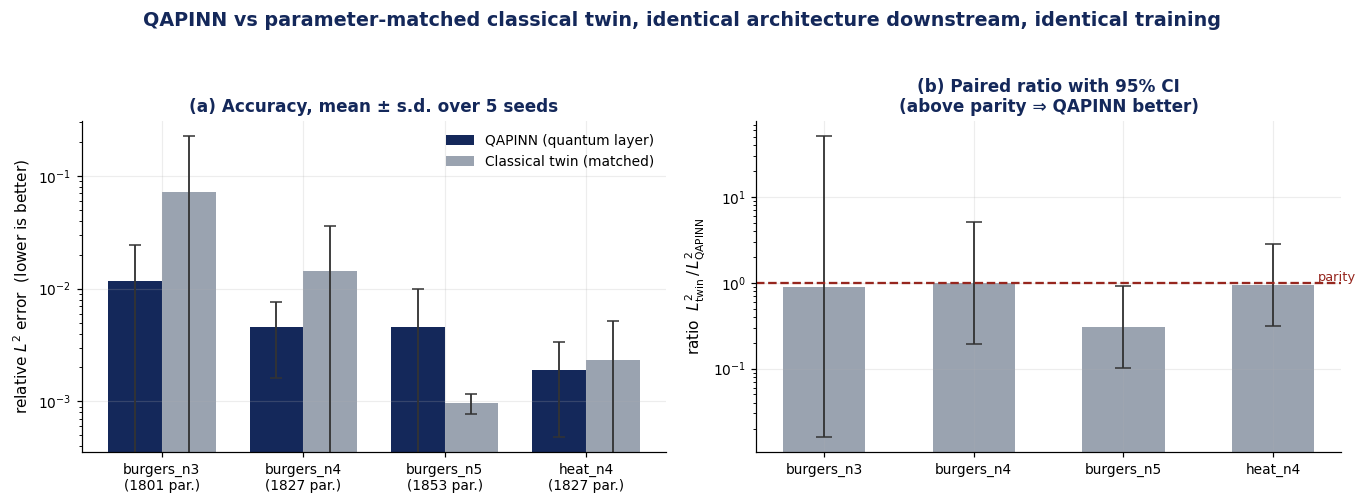

In [32]:
labels = [c[0] for c in CONFIGS if c[0] in STATS]
if labels:
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
    xp = np.arange(len(labels))
    qm = [STATS[l]["q_mean"] for l in labels]; qs = [STATS[l]["q_sd"] for l in labels]
    tm = [STATS[l]["t_mean"] for l in labels]; ts_ = [STATS[l]["t_sd"] for l in labels]

    a = ax[0]
    a.bar(xp-0.19, qm, 0.38, yerr=qs, capsize=4, color=C_Q,
          label="QAPINN (quantum layer)", error_kw=dict(lw=1.2, ecolor="#333333"))
    a.bar(xp+0.19, tm, 0.38, yerr=ts_, capsize=4, color=C_T,
          label="Classical twin (matched)", error_kw=dict(lw=1.2, ecolor="#333333"))
    a.set_yscale("log"); a.set_xticks(xp)
    a.set_xticklabels([f"{l}\n({QAPINN_PARAMS[STATS[l]['n_feat']]} par.)" for l in labels],
                      fontsize=9)
    a.set_ylabel("relative $L^2$ error  (lower is better)")
    a.set_title(f"(a) Accuracy, mean ± s.d. over {N_SEEDS} seeds", weight="bold", color=C_Q)
    a.legend(frameon=False)

    a = ax[1]
    ratios = [STATS[l]["ratio"] for l in labels]
    los = [STATS[l]["ratio"]-STATS[l]["ci"][0] for l in labels]
    his = [STATS[l]["ci"][1]-STATS[l]["ratio"] for l in labels]
    cols = [C_Q if r > 1 else C_T for r in ratios]
    a.bar(xp, ratios, 0.55, yerr=[los, his], capsize=5, color=cols,
          error_kw=dict(lw=1.2, ecolor="#333333"))
    a.axhline(1.0, ls="--", lw=1.5, color=C_REF)
    a.text(len(labels)-0.45, 1.04, "parity", color=C_REF, fontsize=8.5, ha="right")
    a.set_yscale("log"); a.set_xticks(xp); a.set_xticklabels(labels, fontsize=9)
    a.set_ylabel(r"ratio  $L^2_{\rm twin}\,/\,L^2_{\rm QAPINN}$")
    a.set_title("(b) Paired ratio with 95% CI\n(above parity ⇒ QAPINN better)",
                weight="bold", color=C_Q)
    
    fig.suptitle("QAPINN vs parameter-matched classical twin, identical architecture "
                 "downstream, identical training",
                 fontsize=12.5, weight="bold", color=C_Q, y=1.03)
    plt.tight_layout(); savefig(fig, "F1_headline_comparison"); plt.show()

### Figure 2 : Seed spread (reproducibility evidence)


[fig] F2_seed_spread.png / .pdf


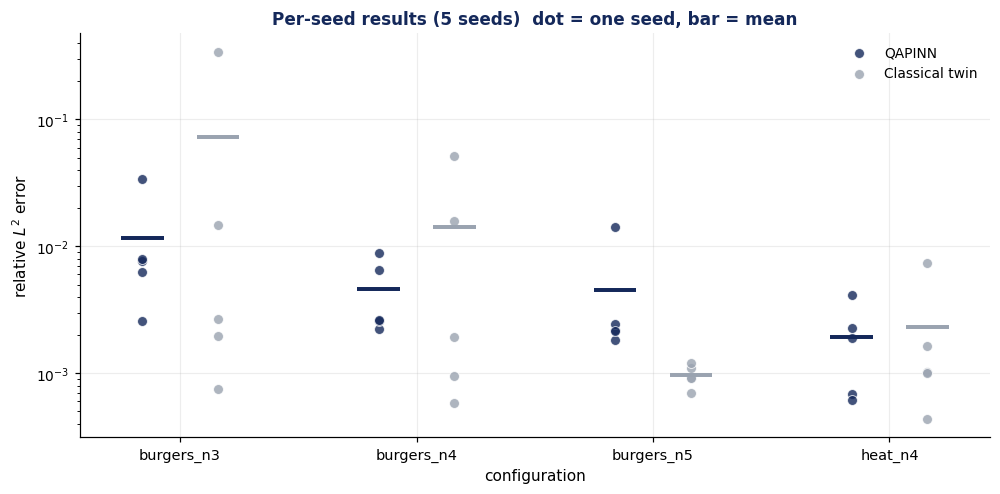

In [33]:
if labels:
    fig, ax = plt.subplots(figsize=(9.2, 4.6))
    for i, l in enumerate(labels):
        for k, (kind, col, off) in enumerate([("qapinn", C_Q, -0.16), ("twin", C_T, 0.16)]):
            v = [RESULTS[(l,kind,s)]["l2"] for s in SEEDS if (l,kind,s) in RESULTS]
            if not v: continue
            ax.scatter([i+off]*len(v), v, s=42, color=col, alpha=0.8, zorder=3,
                       edgecolor="white", linewidth=0.6,
                       label=("QAPINN" if (i==0 and k==0) else
                              ("Classical twin" if (i==0 and k==1) else None)))
            ax.hlines(np.mean(v), i+off-0.09, i+off+0.09, color=col, lw=2.6, zorder=4)
    ax.set_yscale("log"); ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9.5)
    ax.set_ylabel("relative $L^2$ error"); ax.set_xlabel("configuration")
    ax.set_title(f"Per-seed results ({N_SEEDS} seeds)  dot = one seed, bar = mean",
                 weight="bold", color=C_Q)
    ax.legend(frameon=False)
    plt.tight_layout(); savefig(fig, "F2_seed_spread"); plt.show()

### Figure 3 : Per-neuron activation profiles


[fig] F3_neuron_profiles_burgers_n5_L1.png / .pdf


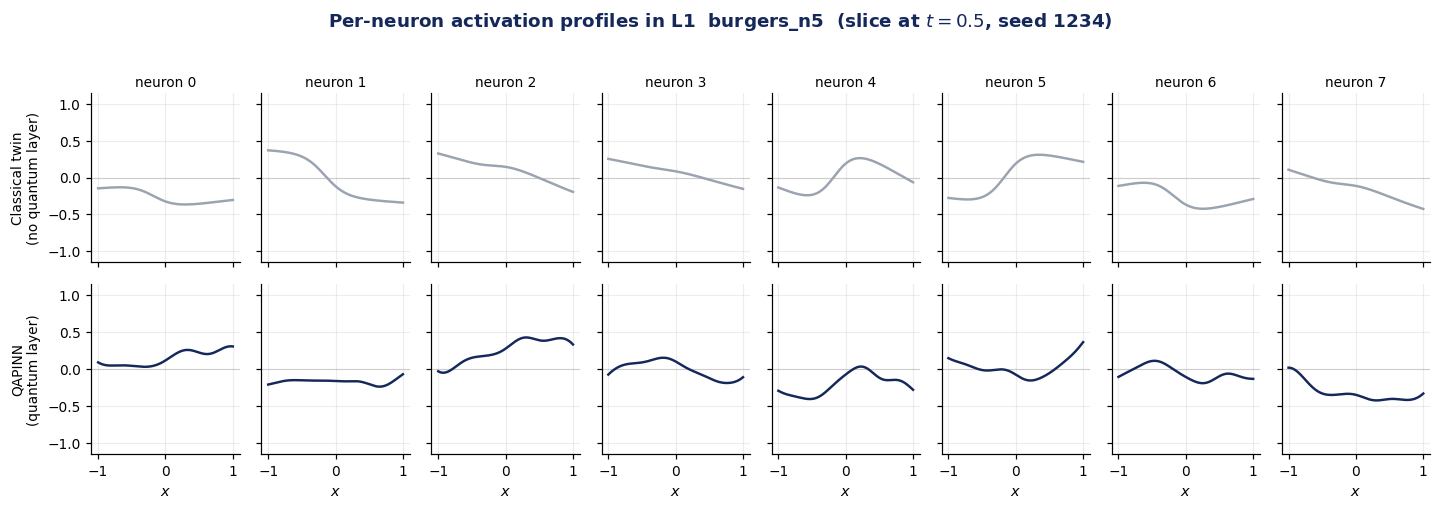

In [34]:
def fig_neuron_profiles(label, layer="L1", n_show=8, seed=None):
    seed = seed or SEEDS[0]
    kq, kt = (label, "qapinn", seed), (label, "twin", seed)
    if kq not in ACTS or kt not in ACTS:
        print(f"[skip] {label}"); return
    A, B = ACTS[kq].get(layer), ACTS[kt].get(layer)
    if A is None or B is None:
        print(f"[skip] layer {layer}"); return
    xs = np.linspace(-1, 1, A.shape[0])
    ncol = min(n_show, A.shape[1], B.shape[1])
    fig, axs = plt.subplots(2, ncol, figsize=(1.65*ncol, 4.5),
                            sharex=True, sharey=True, squeeze=False)
    for r, (M, lab, col) in enumerate([(B, "Classical twin\n(no quantum layer)", C_T),
                                       (A, "QAPINN\n(quantum layer)", C_Q)]):
        for j in range(ncol):
            a = axs[r, j]
            a.plot(xs, M[:, j], color=col, lw=1.6)
            a.axhline(0, color="#d5d5d5", lw=0.7, zorder=0)
            a.set_ylim(-1.15, 1.15)
            if r == 0: a.set_title(f"neuron {j}", fontsize=9, pad=4)
            if j == 0: a.set_ylabel(lab, fontsize=9)
            else: a.tick_params(labelleft=False)
            if r == 1: a.set_xlabel("$x$", fontsize=9.5)
    fig.suptitle(f"Per-neuron activation profiles in {layer}  {label}  "
                 f"(slice at $t=0.5$, seed {seed})",
                 fontsize=12, weight="bold", color=C_Q, y=1.02)
    plt.tight_layout(); savefig(fig, f"F3_neuron_profiles_{label}_{layer}"); plt.show()

for cand in ["burgers_n5", "burgers_n4", "burgers_n3"]:
    if (cand, "qapinn", SEEDS[0]) in ACTS:
        fig_neuron_profiles(cand, "L1"); break

### Figure 4 : Neuron health histograms


[fig] F4_histograms_burgers_n5_qapinn.png / .pdf


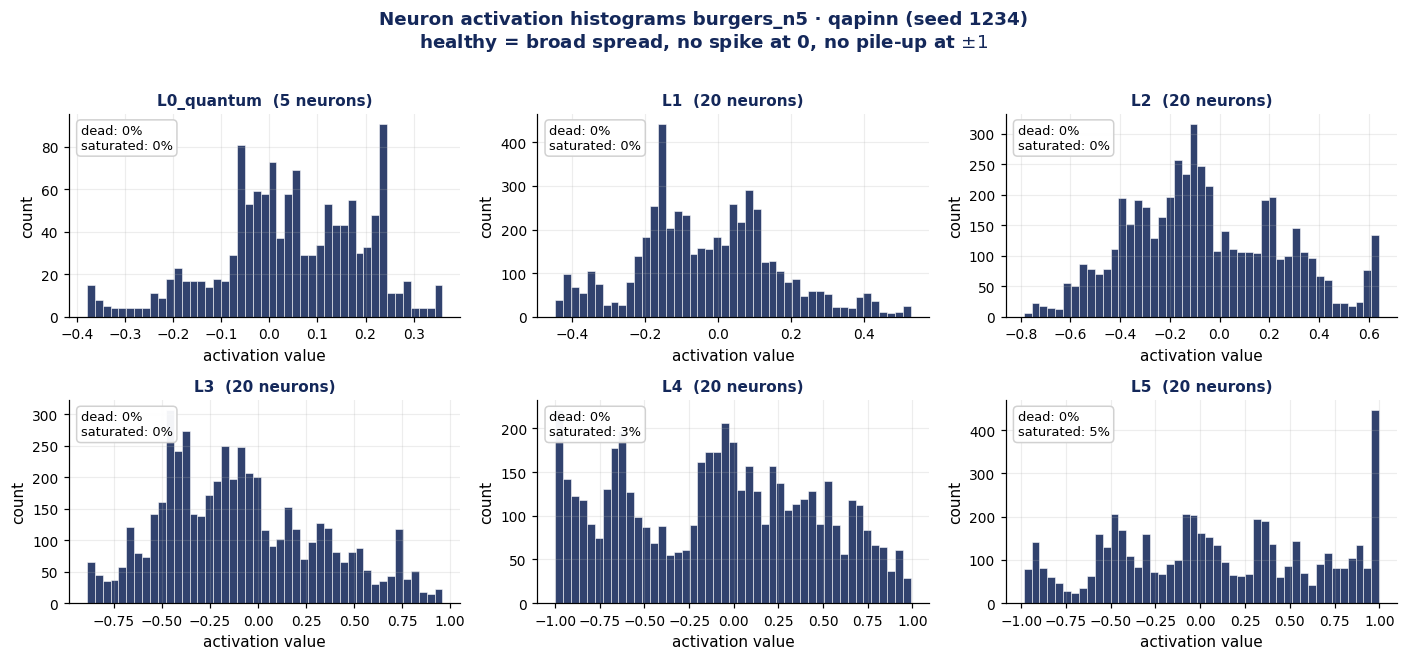

In [35]:
def fig_neuron_histograms(label, kind="qapinn", seed=None):
    seed = seed or SEEDS[0]
    key = (label, kind, seed)
    if key not in ACTS: print(f"[skip] {label}"); return
    acts = ACTS[key]; names = list(acts.keys())
    ncol = 3; nrow = int(np.ceil(len(names)/ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(4.3*ncol, 2.95*nrow), squeeze=False)
    for i, L in enumerate(names):
        a = axs[i//ncol, i % ncol]; A = acts[L]
        a.hist(A.ravel(), bins=45, color=C_Q, alpha=0.88,
               edgecolor="white", linewidth=0.4)
        a.set_title(f"{L}  ({A.shape[1]} neurons)", fontsize=10, weight="bold", color=C_Q)
        a.set_xlabel("activation value"); a.set_ylabel("count")
        dead = float(np.mean(np.abs(A).max(axis=0) < 1e-3)*100)
        sat = float(np.mean(np.abs(A.ravel()) > 0.99)*100)
        a.text(0.03, 0.95, f"dead: {dead:.0f}%\nsaturated: {sat:.0f}%",
               transform=a.transAxes, fontsize=8.5, va="top",
               bbox=dict(boxstyle="round,pad=0.32", fc="white", ec="#cfcfcf", alpha=0.95))
    for j in range(len(names), nrow*ncol):
        axs[j//ncol, j % ncol].axis("off")
    fig.suptitle(f"Neuron activation histograms {label} · {kind} (seed {seed})\n"
                 f"healthy = broad spread, no spike at 0, no pile-up at $\\pm1$",
                 fontsize=12, weight="bold", color=C_Q, y=1.01)
    plt.tight_layout(); savefig(fig, f"F4_histograms_{label}_{kind}"); plt.show()

for cand in ["burgers_n5", "burgers_n4", "burgers_n3"]:
    if (cand, "qapinn", SEEDS[0]) in ACTS:
        fig_neuron_histograms(cand, "qapinn"); break

### Figure 5 : Layer-wise activation heatmaps
All neurons of a layer at once: rows are neurons, columns are $x$. Reveals dead rows (flat) and
saturated rows (pinned at $\pm1$) instantly.

[fig] F5_heatmaps_burgers_n5_qapinn.png / .pdf


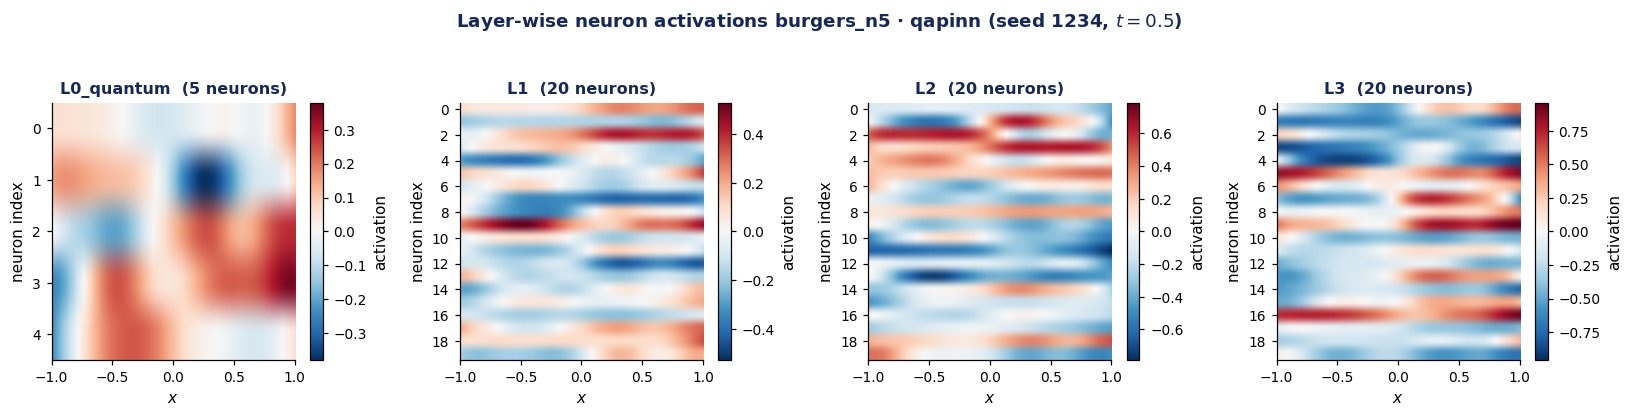

In [36]:
def fig_activation_heatmaps(label, kind="qapinn", seed=None, layers=None):
    seed = seed or SEEDS[0]; key = (label, kind, seed)
    if key not in ACTS: print(f"[skip] {label}"); return
    acts = ACTS[key]
    names = layers or [n for n in list(acts.keys())[:4]]
    xs = np.linspace(-1, 1, acts[names[0]].shape[0])
    fig, axs = plt.subplots(1, len(names), figsize=(3.75*len(names), 3.6), squeeze=False)
    for a, L in zip(axs[0], names):
        A = acts[L]; vmax = float(np.abs(A).max()) or 1.0
        im = a.imshow(A.T, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                      extent=[xs.min(), xs.max(), A.shape[1]-0.5, -0.5])
        a.set_xlabel("$x$"); a.set_ylabel("neuron index")
        a.set_yticks(range(0, A.shape[1], max(1, A.shape[1]//10)))
        a.set_title(f"{L}  ({A.shape[1]} neurons)", fontsize=10.5, weight="bold", color=C_Q)
        a.grid(False)
        plt.colorbar(im, ax=a, label="activation")
    fig.suptitle(f"Layer-wise neuron activations {label} · {kind} (seed {seed}, $t=0.5$)",
                 fontsize=12, weight="bold", color=C_Q, y=1.04)
    plt.tight_layout(); savefig(fig, f"F5_heatmaps_{label}_{kind}"); plt.show()

for cand in ["burgers_n5", "burgers_n4", "burgers_n3"]:
    if (cand, "qapinn", SEEDS[0]) in ACTS:
        fig_activation_heatmaps(cand, "qapinn"); break

### Figure 6 : CKA information flow (raw, for Phase-3 interpretation)
Layer-to-layer CKA matrices for both models side by side, plus each layer's CKA with the model
output. **Presented, not interpreted** — Phase 3 WS-C draws the conclusions.

[fig] F6_cka_burgers_n5.png / .pdf


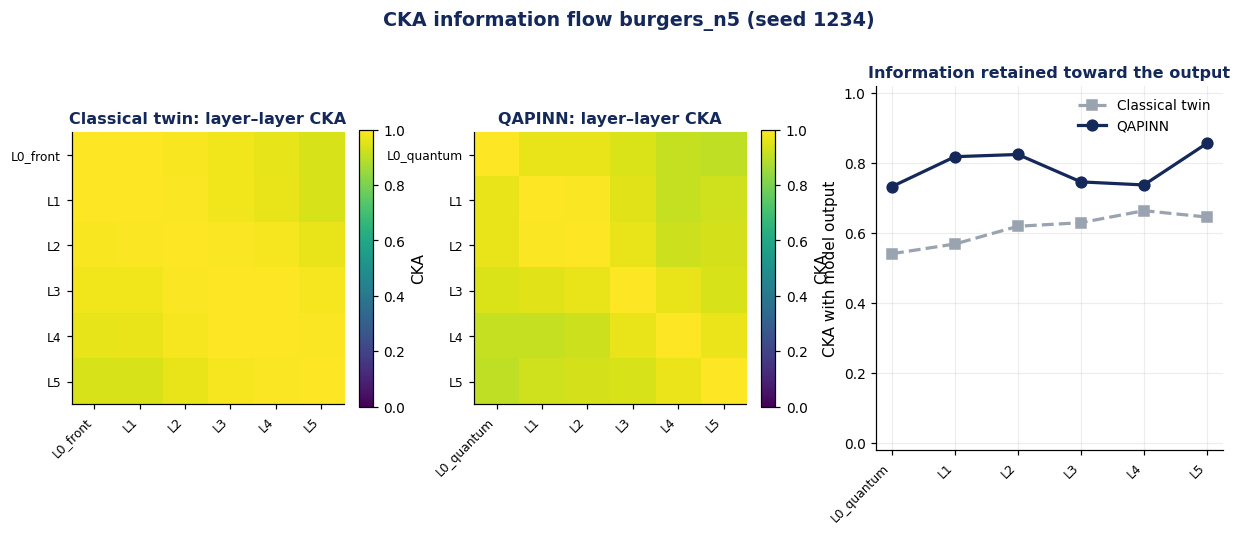

In [37]:
def fig_cka(label, seed=None):
    seed = seed or SEEDS[0]
    kq, kt = (label, "qapinn", seed), (label, "twin", seed)
    if kq not in CKA_STORE or kt not in CKA_STORE:
        print(f"[skip] {label}"); return
    fig = plt.figure(figsize=(13.5, 4.3))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.15], wspace=0.32)
    for i, (key, ttl) in enumerate([(kt, "Classical twin"), (kq, "QAPINN")]):
        d = CKA_STORE[key]; M = d["matrix"]; names = list(d["names"])
        a = fig.add_subplot(gs[0, i])
        im = a.imshow(M, cmap="viridis", vmin=0, vmax=1)
        a.set_xticks(range(len(names))); a.set_yticks(range(len(names)))
        a.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
        a.set_yticklabels(names, fontsize=8)
        a.set_title(f"{ttl}: layer–layer CKA", fontsize=10.5, weight="bold", color=C_Q)
        a.grid(False)
        plt.colorbar(im, ax=a, label="CKA", fraction=0.046)
    a = fig.add_subplot(gs[0, 2])
    for key, lab, col, mk in [(kt, "Classical twin", C_T, "s--"), (kq, "QAPINN", C_Q, "o-")]:
        d = CKA_STORE[key]
        a.plot(range(len(d["names"])), d["to_output"], mk, lw=2.1, ms=7, color=col, label=lab)
    a.set_xticks(range(len(CKA_STORE[kq]["names"])))
    a.set_xticklabels(list(CKA_STORE[kq]["names"]), rotation=45, ha="right", fontsize=8)
    a.set_ylabel("CKA with model output"); a.set_ylim(-0.02, 1.02)
    a.set_title("Information retained toward the output", fontsize=10.5,
                weight="bold", color=C_Q)
    a.legend(frameon=False)
    fig.suptitle(f"CKA information flow {label} (seed {seed})",
                 fontsize=12.5, weight="bold", color=C_Q, y=1.04)
    savefig(fig, f"F6_cka_{label}"); plt.show()

for cand in ["burgers_n5", "burgers_n4", "burgers_n3"]:
    if (cand, "qapinn", SEEDS[0]) in CKA_STORE:
        fig_cka(cand); break

### Figure 7 : Generalization to an unseen time domain
Trained on $t\in[0,1]$, evaluated on $t\in[1,1.5]$. One of the brief's listed metrics, and a
differentiator few teams will report.

[fig] F7_generalization.png / .pdf


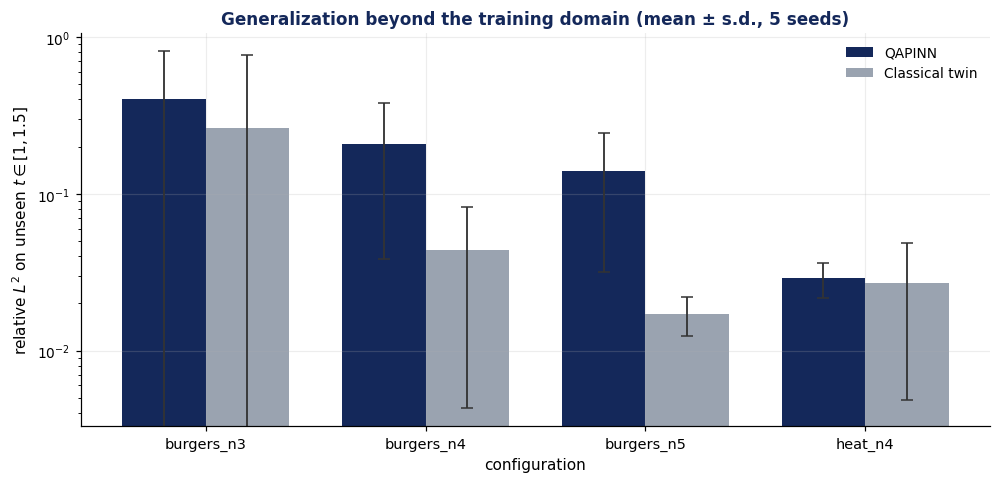

In [28]:
gl = [l for l, *_ in CONFIGS if (l, "qapinn") in GEN and (l, "twin") in GEN]
if gl:
    fig, ax = plt.subplots(figsize=(9.2, 4.5))
    xp = np.arange(len(gl))
    qv = [GEN[(l,"qapinn")][0] for l in gl]; qe = [GEN[(l,"qapinn")][1] for l in gl]
    tv = [GEN[(l,"twin")][0]  for l in gl]; te = [GEN[(l,"twin")][1]  for l in gl]
    ax.bar(xp-0.19, qv, 0.38, yerr=qe, capsize=4, color=C_Q, label="QAPINN",
           error_kw=dict(lw=1.2, ecolor="#333333"))
    ax.bar(xp+0.19, tv, 0.38, yerr=te, capsize=4, color=C_T, label="Classical twin",
           error_kw=dict(lw=1.2, ecolor="#333333"))
    ax.set_yscale("log"); ax.set_xticks(xp); ax.set_xticklabels(gl, fontsize=9.5)
    ax.set_ylabel("relative $L^2$ on unseen $t\\in[1,1.5]$")
    ax.set_xlabel("configuration")
    ax.set_title("Generalization beyond the training domain "
                 f"(mean ± s.d., {N_SEEDS} seeds)", weight="bold", color=C_Q)
    ax.legend(frameon=False)
    plt.tight_layout(); savefig(fig, "F7_generalization"); plt.show()

### Figure 8 : Output Fourier spectra (raw, for WS-A)
Power spectrum of each model's output against the analytical solution at $t=1$. **Cached and shown;
the spectral analysis itself is Phase 3 WS-A.**

[fig] F8_spectrum_burgers_n5.png / .pdf


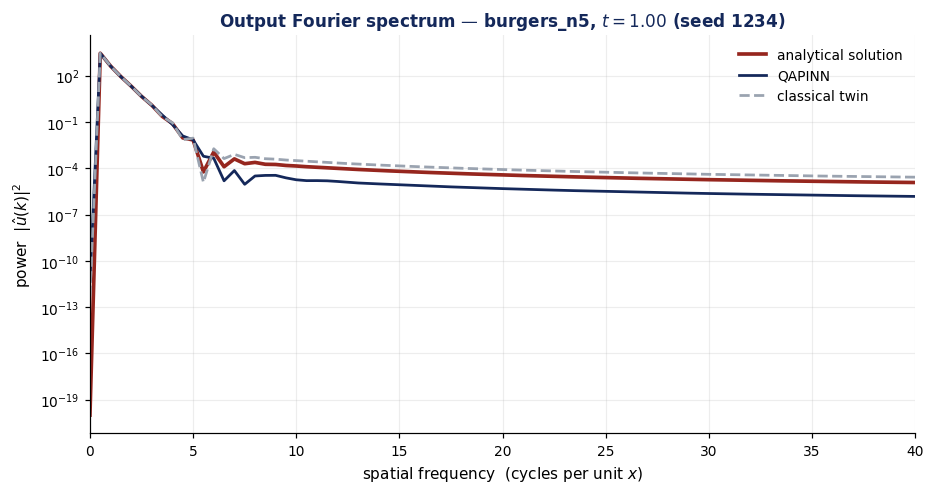

In [ ]:
def fig_spectrum(label, seed=None, t_index=3):
    seed = seed or SEEDS[0]
    kq, kt = (label, "qapinn", seed), (label, "twin", seed)
    if kq not in RESULTS or kt not in RESULTS: print(f"[skip] {label}"); return
    dq = np.load(os.path.join(P3DIR, "spectra", f"{RESULTS[kq]['tag']}_spectrum.npz"))
    dt = np.load(os.path.join(P3DIR, "spectra", f"{RESULTS[kt]['tag']}_spectrum.npz"))
    f = dq["freqs"]; ts = dq["t_slices"][t_index]
    fig, ax = plt.subplots(figsize=(8.6, 4.6))
    ax.semilogy(f, dq["power_exact"][t_index] + 1e-20, lw=2.4, color=C_REF,
                label="analytical solution")
    ax.semilogy(f, dq["power_model"][t_index] + 1e-20, lw=1.8, color=C_Q, label="QAPINN")
    ax.semilogy(f, dt["power_model"][t_index] + 1e-20, lw=1.8, color=C_T, ls="--",
                label="classical twin")
    ax.set_xlabel("spatial frequency  (cycles per unit $x$)")
    ax.set_ylabel("power  $|\\hat u(k)|^2$")
    ax.set_title(f"Output Fourier spectrum  {label}, $t={ts:.2f}$ (seed {seed})",
                 weight="bold", color=C_Q)
    ax.set_xlim(0, min(40, f.max())); ax.legend(frameon=False)
    plt.tight_layout(); savefig(fig, f"F8_spectrum_{label}"); plt.show()

for cand in ["burgers_n5", "burgers_n4", "burgers_n3"]:
    if (cand, "qapinn", SEEDS[0]) in RESULTS:
        fig_spectrum(cand); break

---
# 4. Export manifest for Phase 3

In [30]:
manifest = {
    "created": time.strftime("%Y-%m-%d %H:%M"),
    "phase": "2-final (Track A, Djabon)",
    "seeds": SEEDS,
    "configs": [{"label": l, "pde": p, "nu": float(n), "n_features": nf}
                for l, p, n, nf in CONFIGS],
    "architecture": {
        "qapinn": "VQC (6 layers, all-to-all, <Z>, full re-uploading, trainable input scale) "
                  "+ deep classical body 20x5",
        "twin": "Linear(2,H)->tanh->Linear(H,n) + identical deep body, exact parameter parity",
        "params": QAPINN_PARAMS},
    "schedule": "Adam 1000 (lr 8e-3) -> L-BFGS 1000 (chunks of 200)",
    "statistics": {k: {"ratio": v["ratio"], "ci": list(v["ci"]), "p": v["p"],
                       "n_seeds": v["n"]} for k, v in STATS.items()},
    "phase3_inputs": {
        "WS-A (Fourier)": "phase3_inputs/spectra/*_spectrum.npz (output power vs analytical), "
                          "*_neuron_spectra.npz (per-neuron activation spectra)",
        "WS-B (trainability)": "phase3_inputs/gradients/gradient_variance.npz "
                               "(n=3,4,5 here; full 3-7 curve is Roland's B13-B14)",
        "WS-C (CKA / neuron XAI)": "phase3_inputs/cka_*.npz (layer-layer + to-output CKA), "
                                   "phase3_inputs/activations/*_acts.npz (per-neuron)"},
    "metrics_table": "phase3_inputs/metrics_table.csv",
    "excluded_by_design": [
        "entanglement/measurement/depth ablation -> Roland Track B",
        "barren-plateau curve across qubit counts -> Roland B13-B14",
        "CKA and Fourier interpretation -> Phase 3",
        "loss landscape / Hessian -> Phase 3 WS-B / stretch",
        "design methodology -> Phase 4"],
}
with open(os.path.join(P3DIR, "manifest.json"), "w") as fh:
    json.dump(manifest, fh, indent=2)

print("PHASE-3 INPUT BUNDLE READY\n" + "="*52)
for root, _, files in os.walk(P3DIR):
    rel = os.path.relpath(root, P3DIR)
    if files:
        print(f"  {rel if rel != '.' else '(root)'}: {len(files)} files")
n_dead = sum(1 for r in RESULTS.values() if r["dead"])
print(f"\ntraining runs completed: {len(RESULTS)}")
print(f"dead runs remaining after retry: {n_dead}"
      + ("  <-- investigate before reporting" if n_dead else "  (none)"))
print(f"figures: {FIGDIR}/  (PNG 300 dpi + vector PDF)")

PHASE-3 INPUT BUNDLE READY
  (root): 43 files
  activations: 40 files
  spectra: 80 files
  generalization: 1 files
  gradients: 1 files

training runs completed: 40
dead runs remaining after retry: 0  (none)
figures: qapinn_runs/figures/  (PNG 300 dpi + vector PDF)
